# Do diverse topic ties predict concept spread? A co-occurrence emergence screen on OpenAlex

This notebook is a runnable demo of the experiment artifact **`gen_art_experiment_3`** from the research project
*"Exploring emerging scientific concepts through evolving knowledge networks"* (OpenAlex, 2000–2014).

**Question.** Does a concept's *early structural position* in the topic co-occurrence network tell us whether it later
**spreads across disciplines** (the breadth outcome `O2r`), beyond what simple volume/growth/breadth measures already say?
Two candidate network indicators are screened against a 5-feature reference baseline **B5**
(`logvol, growth, offhome_share, entropy, nfields2`):

* **D (structural diversity)**: how many distinct backbone communities the concept's early topic neighbours span,
  relative to a frequency-matched null (`D_ratio`; the plan's literal `D_z` failed a size diagnostic, see deviations).
* **F (frequency-free selectivity)**: how selectively the concept attaches to topics, beyond their background prevalence (`F_res`).

**What `method.py` does.** It orchestrates 9 steps: (1) S0 yearly counts from the OpenAlex API, (2–3) a zero-credit,
column-pruned scan of all **476M works** of the OpenAlex S3 snapshot, (4) outcomes and the B5 baseline,
(5) a full-corpus topic-PMI backbone with Leiden communities, (6) about 30 ego-network indicators,
(7) the **screen**: leave-one-home-field-group-out (LOGO) ridge/logit models with a stratified concept bootstrap and a
pre-registered selection rule, (8) exploratory analyses, (9) outputs.

**What this demo runs.** Steps 1–6 need the full snapshot scan (hundreds of GB, hours), so their per-concept outputs
for the **47 dev concepts** (BIO 16, CS 12, MED 10, ENG 9) are loaded from `mini_demo_data.json`. **Step 7 (the whole
screen: `screen.py`) runs live**, with the original code and the original bootstrap sizes (2,000 / 1,000). This takes
about 2–3 minutes on a CPU. Lower `N_BOOT` in the config cell for a quicker run.

Reported full-run result (2,000 bootstraps): B5 alone reaches ρ≈0.770 with `O2r`; D_ratio Δρ = +0.006
[90% CI −0.092, 0.135]; F_res Δρ = −0.060 [−0.158, 0.014]. **No candidate survives the pre-registered rule.** The demo
reproduces these numbers: the point estimates are deterministic, and the bootstrap uses the same per-resample seeds.

## 1. Setup: install dependencies
`loguru` is not pre-installed on Colab. The scientific stack is pinned to Colab's versions and installed only when running outside Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, sklearn, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

## 2. Imports
The import block of `method.py` (orchestrator), then that of `screen.py` (step 7). The BLAS thread cap comes first, as in `screen.py`. `matplotlib` is added for the final figures.

In [2]:
from __future__ import annotations

# ---- method.py imports
import argparse
import json
import resource
import subprocess
import sys
import time

from loguru import logger

# ---- screen.py imports
import os

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # tiny models: avoid BLAS thread oversubscription across bootstrap workers

import math
import multiprocessing as mp
import warnings
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ---- notebook additions
from pathlib import Path
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## 3. Data loading helper
The notebook loads `mini_demo_data.json` from GitHub, and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/main/round-1/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print({k: v for k, v in data["metadata"].items() if k != "description"})
print("first concept:", data["examples"][0]["concept"], "| keys:", list(data["examples"][0].keys()))

47 dev concepts of the frozen P78 panel (S0 protocol). Each record = one concept with the rows of outcomes.csv, features_ego.csv, field_outcomes_base.csv+field_features.csv and reliability_splits.csv that belong to it (outputs of pipeline steps 1-6, which need the 476M-work OpenAlex S3 snapshot scan).
{'n_concepts': 47, 'n_field_rows': 129, 'n_field_rows_total_in_source': 129, 'n_dropped_concepts_not_included': 31}
first concept: zinc finger nuclease | keys: ['concept', 'outcomes_row', 'features_ego_row', 'field_rows', 'reliability_rows']


## 4. Configuration
All tunable parameters are set here. The bootstrap resamples are the only expensive part of the screen, and they scale
linearly. The original full run used `--n_boot 2000` (main screen and field level). It used `min(n_boot, 1000)` for the
`reach30` hurdle and each sensitivity analysis, and 4 spawn workers.

In [5]:
N_BOOT = 2000         # concept-bootstrap resamples for the main screen      (original: 2000; 400 -> ~45 s total)
N_BOOT_SIDE_CAP = 1000 # cap for hurdle/sensitivity bootstraps               (original: 1000, i.e. min(n_boot, 1000))
SEED = 20260928       # bootstrap seed                                        (original: 20260928)
N_WORKERS = 1         # 1 = run bootstrap in-process (notebook-safe)          (original: 4 spawn workers)
TAG = ""              # suffix for results/screen_result{TAG}.json

# ---- frozen protocol constants (from config.py; not tunable)
DEV_FIELDS = {17: "Computer Science", 22: "Engineering", 13: "Biochemistry, Genetics and Molecular Biology",
              27: "Medicine"}
GROUP_SHORT = {17: "CS", 22: "ENG", 13: "BIO", 27: "MED"}
DROPPED_ALIASES = [{"concept": "natural orifice transluminal endoscopic surgery", "alias": "NOTES",
                    "reason": "common English word; case-insensitive stemmed phrase search would match 'notes'"}]
# paths (config.py derived them from the script location; here: the notebook's working directory)
ROOT = Path(".").resolve()
RES = ROOT / "results"
LOGS = ROOT / "logs"
for _d in (RES, LOGS):
    _d.mkdir(parents=True, exist_ok=True)

## 5. The orchestrator (`method.py`)
This is `method.py`'s step list, its record of protocol deviations and its `run`/`main` driver, copied unchanged.
Each step is a separate script launched as a subprocess. `main()` is **defined but not called** here, because steps 1–6
need the OpenAlex snapshot scan. The deviations are still written to `results/deviations.json`, as `main()` would do.
Read them: they explain *why* `D_ratio` (not `D_z`) is the primary D, why compositions use title matches, and so on.

In [6]:
PY = sys.executable
STEPS = ["s0_fetch", "snapshot_meta", "scan_snapshot", "s0_outcomes", "backbone", "features", "screen",
         "extra_analyses", "make_outputs"]

DEVIATIONS = DROPPED_ALIASES + [
    {"id": "API_KEY_EXHAUSTED", "what": "The shared OpenAlex key had 0 credits left (x-ratelimit-remaining=0, reset "
     "~11.7 h) when this artifact started. API use was limited to the S0 yearly counts (78 concepts + global + OR test, "
     "156 credits in total) on the public per-IP anonymous pool (1,000/day; >= 800 left for siblings).",
     "consequence": "All other data (venue windows, ego networks, backbone, background prevalence) come from the free "
     "OpenAlex S3 works snapshot (2026-09-23; 476M works) at 0 credits."},
    {"id": "TITLE_GROUNDING_FOR_COMPOSITION", "what": "Venue-field compositions (home field, O2r, R_j, early "
     "off-home share/entropy/reach) and ego topic counts use TITLE-matched base works from the snapshot "
     "(OpenAlex-like analysis: lowercase, possessive strip, stop words with position gaps, Porter stemming, "
     "positional phrase match), not title+abstract matches, because abstracts are 43% of the snapshot bytes. "
     "t0, newborn, O1, O3, log volume and growth use the S0-exact API title+abstract counts.",
     "consequence": "Lower recall (see sanity.median_title_share_of_api_early), higher topical precision; field "
     "compositions are estimated from the papers that name the concept in the title."},
    {"id": "HOME_WINDOW_WIDENED", "what": "If fewer than 5 labelled title-matched papers exist in t0..t0+1, the home "
     "field is decided on t0..t0+2 (flag home_window in outcomes.csv)."},
    {"id": "FULL_CORPUS_BACKBONE", "what": "The backbone uses ALL base works of each slice (millions) instead of "
     "10k-work samples, and exact yearly background prevalence instead of slice-level log-linear interpolation "
     "(plan departures 2 and 3 are removed)."},
    {"id": "GAMMA_RULE", "what": "On the dense full-corpus backbone the plan's rule (gamma maximising median standard "
     "modularity) picks gamma=1, which leaves only ~8 communities of ~500 topics, outside the plan's expected 'tens to a "
     "few hundred' (T2). BEFORE any outcome was inspected, the primary gamma was redefined as the highest-median-Q gamma "
     "whose median number of non-trivial communities is >= 20; the plan-rule partition is reported as D_q."},
    {"id": "SELF_TOPIC_LEXICAL_RULE", "what": "A literal 'shares one content lemma' rule flagged generic topics as "
     "SELF (e.g. 'cell' -> 30 topics for iPSC, 'sensing' -> Remote Sensing for compressed sensing, 'comparative' -> "
     "legal studies). The lexical SELF rule was tightened (before outcomes were inspected) to: the topic name contains "
     "ALL content lemmas (lemma occurring in <= 100 topic names) of at least one of the concept's phrases; the >= 20% "
     "paper-share rule is unchanged. 16 of 47 dev concepts get a lexical self topic (e.g. compressed sensing -> "
     "'Sparse and Compressive Sensing Techniques')."},
    {"id": "D_PRIMARY_FALLBACK_T3", "what": "T3 STOP-AND-FIX fired: 70% of dev concepts have D_z < -5 and "
     "Spearman(D_z, M) = -0.69 (with log early volume -0.63): the frequency-matched null draws from all of science "
     "while real neighbours are topically concentrated, so z scales with M. Per the plan's pre-stated fallback, and "
     "decided on outcome-blind diagnostics only, the primary D is the one of D_ratio / D_rare with the smaller "
     "|Spearman| with M: D_ratio (obs distinct communities / null mean; 0.23 vs 0.29). D_z is still screened and "
     "reported as 'D_z_literal' (not ranked)."},
    {"id": "SPLIT_HALF_PAPER_LEVEL", "what": "Split-half reliability uses real paper-level random halves (paper topic "
     "lists are available from the snapshot) instead of binomial thinning of aggregate counts (plan departure 7)."},
    {"id": "EGO_WINDOWS_EXACT", "what": "Ego windows are exact paper sets per year, so first-appearance years of new "
     "neighbours are yearly (plan departure 4 no longer binds)."},
    {"id": "CENTRALITY_ON_KNN_BACKBONE", "what": "Betweenness/k-core/constraint of the inserted concept node are "
     "computed on a kNN-sparsified (top-10 PMI edges per topic), unweighted copy of the slice backbone, for runtime."},
    {"id": "COMPRESSED_SENSING_ALIAS", "what": "The OR-syntax test showed 'compressed sensing' and 'compressive "
     "sensing' return identical counts (same Porter stem), so the alias adds nothing; the pipe syntax was frozen."},
]


def run(step: str, extra: list[str]) -> None:
    t = time.time()
    cmd = [PY, str(ROOT / f"{step}.py")] + extra
    logger.info(f"=== {step}: {step}.py {' '.join(extra)}")
    r = subprocess.run(cmd, cwd=ROOT)
    if r.returncode != 0:
        raise RuntimeError(f"step {step} failed with exit code {r.returncode}")
    logger.info(f"=== {step} done in {(time.time() - t) / 60:.1f} min")


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default="s0_fetch", choices=STEPS)
    ap.add_argument("--to", dest="stop", default="make_outputs", choices=STEPS)
    ap.add_argument("--n_boot", type=int, default=2000)
    ap.add_argument("--workers", type=int, default=4)
    a = ap.parse_args()
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(LOGS / "method.log", rotation="30 MB", level="DEBUG")
    ram = 20 * 1024 ** 3  # container limit is 29 GB; the scan aggregates need < 6 GB
    resource.setrlimit(resource.RLIMIT_AS, (ram * 3, ram * 3))
    (RES / "deviations.json").write_text(json.dumps(DEVIATIONS, indent=1))
    todo = STEPS[STEPS.index(a.start): STEPS.index(a.stop) + 1]
    for s in todo:
        if s == "s0_fetch" and (RES / "yearly_counts_api.json").exists():
            logger.info("s0_fetch: cached results present, skipping (no credits)")
            continue
        if s == "snapshot_meta" and (RES / "source_field.parquet").exists():
            logger.info("snapshot_meta: present, skipping")
            continue
        extra = {"screen": ["--n_boot", str(a.n_boot), "--workers", str(a.workers)],
                 "features": ["--workers", str(a.workers)],
                 "scan_snapshot": ["--workers", "6"]}.get(s, [])
        run(s, extra)

# Notebook: main() is not called (steps 1-6 need the 476M-work snapshot scan). Do its first side effect only:
(RES / "deviations.json").write_text(json.dumps(DEVIATIONS, indent=1))
print("pipeline steps :", " -> ".join(STEPS))
print("precomputed    :", STEPS[:6], "(loaded from mini_demo_data.json)")
print("run live below :", STEPS[6], "(screen.py)")
print("deviations     :", [d.get("id", d.get("alias")) for d in DEVIATIONS])

pipeline steps : s0_fetch -> snapshot_meta -> scan_snapshot -> s0_outcomes -> backbone -> features -> screen -> extra_analyses -> make_outputs
precomputed    : ['s0_fetch', 'snapshot_meta', 'scan_snapshot', 's0_outcomes', 'backbone', 'features'] (loaded from mini_demo_data.json)
run live below : screen (screen.py)
deviations     : ['NOTES', 'API_KEY_EXHAUSTED', 'TITLE_GROUNDING_FOR_COMPOSITION', 'HOME_WINDOW_WIDENED', 'FULL_CORPUS_BACKBONE', 'GAMMA_RULE', 'SELF_TOPIC_LEXICAL_RULE', 'D_PRIMARY_FALLBACK_T3', 'SPLIT_HALF_PAPER_LEVEL', 'EGO_WINDOWS_EXACT', 'CENTRALITY_ON_KNN_BACKBONE', 'COMPRESSED_SENSING_ALIAS']


## 6. Restore the step 1–6 output tables from the demo data
`screen.py` reads five CSVs from `results/`. The demo data stores their rows grouped per concept, so this cell writes
the CSVs back. The original `screen.py` code can then read them unchanged.
* `outcomes.csv`: per concept, t0 onset, home group, **outcomes** (`O2r` = rarefied off-home breadth at t0+6..8,
  `O1` sustained uptake, `O3` transient spike, `reach30`), and the **B5** baseline features.
* `features_ego.csv`: about 45 ego-network indicators on the topic backbone (D/F variants, novelty, degree/strength
  growth, new-edge rate, persistence, participation, community transitions, betweenness, constraint…).
* `field_outcomes_base.csv` + `field_features.csv`: concept × off-home field rows, with the field-level outcome `R_j`
  (does the concept reach field j) and the features `Dj`/`Fj`.
* `reliability_splits.csv`: 50 paper-level random split-halves per concept for `D_z`, `F_res`, `D_ratio`.

In [7]:
ex = data["examples"]
pd.DataFrame([e["outcomes_row"] for e in ex]).to_csv(RES / "outcomes.csv", index=False)
pd.DataFrame([e["features_ego_row"] for e in ex if e["features_ego_row"]]).to_csv(RES / "features_ego.csv", index=False)
_fr = pd.DataFrame([r for e in ex for r in e["field_rows"]])
_fr[["concept", "field", "group", "R_j", "n_j_early", "logn_j_early", "growth_j", "share_j", "n_j_WO", "share_j_WO"]] \
    .to_csv(RES / "field_outcomes_base.csv", index=False)
_fr[["concept", "field", "Dj", "Fj", "Fj_missing"]].to_csv(RES / "field_features.csv", index=False)
pd.DataFrame([r for e in ex for r in e["reliability_rows"]]).to_csv(RES / "reliability_splits.csv", index=False)
for f in ("outcomes.csv", "features_ego.csv", "field_outcomes_base.csv", "field_features.csv", "reliability_splits.csv"):
    print(f"{f:28s} rows={len(pd.read_csv(RES / f)):5d}")

outcomes.csv                 rows=   47
features_ego.csv             rows=   47
field_outcomes_base.csv      rows=  129
field_features.csv           rows=  129


reliability_splits.csv       rows= 2350


## 7. Step 7: the screen (`screen.py`)
The docstring of `screen.py` describes the design:

> Leave-one-home-field-group-out (LOGO) prediction: train on 3 dev groups, predict the 4th; standardised ridge
> (alpha=1) for O2r, L2 logistic (C=1) for binary outcomes; B5 vs B5+candidate under identical folds.
> Missing candidate values are imputed with the training-fold median plus a missing-indicator column.
> Bootstrap: 2,000 resamples of CONCEPTS stratified by home group (each group keeps its n); the whole LOGO is
> refitted in every resample. Field-level R_j: concept-clustered bootstrap (resample concepts, keep all rows).

### 7a. Feature sets and models
`B5` is the reference baseline; `BF` is the field-level baseline. `PRIMARY` maps the screened candidates to their columns.
The logistic model is an exact Newton–Raphson solver of the sklearn `LogisticRegression(C=1)` objective, which is fast
enough to refit thousands of times.

In [8]:
B5 = ["logvol", "growth", "offhome_share", "entropy", "nfields2"]
BF = ["logn_j_early", "growth_j", "share_j"]
# D: the plan's literal primary D_z failed the T3 STOP-AND-FIX size diagnostic (70% of D_z < -5,
# Spearman(D_z, M) = -0.69, with log volume -0.63; computed before any outcome was inspected), so the pre-declared
# fallback (the one of D_ratio / D_rare with the smaller |Spearman| with M) is primary: D_ratio (0.23 vs 0.29).
# D_z is still screened and reported as 'D_z_literal'.
PRIMARY = {"D": "D_ratio", "F": "F_res", "D_z_literal": "D_z"}
SCREENED = ("D", "F")


# ----------------------------------------------------------------------------- models
def _prep(Xtr: np.ndarray, Xte: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Median-impute (train medians) + missing flags for columns with NaN, then standardise on train."""
    Xtr = Xtr.astype(float).copy()
    Xte = Xte.astype(float).copy()
    flags_tr, flags_te = [], []
    for j in range(Xtr.shape[1]):
        mtr, mte = np.isnan(Xtr[:, j]), np.isnan(Xte[:, j])
        if mtr.any() or mte.any():
            med = np.nanmedian(Xtr[:, j]) if (~mtr).any() else 0.0
            Xtr[mtr, j] = med
            Xte[mte, j] = med
            if mtr.any() and (~mtr).any():
                flags_tr.append(mtr.astype(float))
                flags_te.append(mte.astype(float))
    if flags_tr:
        Xtr = np.column_stack([Xtr] + flags_tr)
        Xte = np.column_stack([Xte] + flags_te)
    mu = Xtr.mean(0)
    sd = Xtr.std(0)
    sd[sd == 0] = 1.0
    return (Xtr - mu) / sd, (Xte - mu) / sd


def ridge_fit_predict(Xtr, ytr, Xte, alpha: float = 1.0) -> np.ndarray:
    Xtr, Xte = _prep(Xtr, Xte)
    ym = ytr.mean()
    A = Xtr.T @ Xtr + alpha * np.eye(Xtr.shape[1])
    beta = np.linalg.solve(A, Xtr.T @ (ytr - ym))
    return ym + Xte @ beta


def logit_newton(X: np.ndarray, y: np.ndarray, C: float = 1.0, iters: int = 100, tol: float = 1e-10) -> np.ndarray:
    """Exact minimiser of 0.5*||w||^2 + C*sum(logloss) with an unpenalised intercept (the sklearn
    LogisticRegression(C=1) objective), by Newton-Raphson; returns [b, w]."""
    n, p = X.shape
    Z = np.column_stack([np.ones(n), X])
    beta = np.zeros(p + 1)
    R = np.eye(p + 1) / C
    R[0, 0] = 0.0
    for _ in range(iters):
        eta = Z @ beta
        mu = 1.0 / (1.0 + np.exp(-eta))
        g = Z.T @ (mu - y) + R @ beta
        H = (Z * (mu * (1 - mu))[:, None]).T @ Z + R + 1e-12 * np.eye(p + 1)
        step = np.linalg.solve(H, g)
        beta -= step
        if np.abs(step).max() < tol:
            break
    return beta


def logit_fit_predict(Xtr, ytr, Xte) -> np.ndarray:
    if len(np.unique(ytr)) < 2:
        return np.full(len(Xte), ytr.mean())
    Xtr, Xte = _prep(Xtr, Xte)
    beta = logit_newton(Xtr, ytr.astype(float))
    return 1.0 / (1.0 + np.exp(-(beta[0] + Xte @ beta[1:])))


def logit_fit_predict_sklearn(Xtr, ytr, Xte) -> np.ndarray:
    """Reference implementation (used only in the equivalence check)."""
    Xtr, Xte = _prep(Xtr, Xte)
    m = LogisticRegression(C=1.0, max_iter=5000, tol=1e-10)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]


def logo(X: np.ndarray, y: np.ndarray, groups: np.ndarray, kind: str) -> np.ndarray:
    # leave-one-group-out: every home-field group is predicted by a model trained on the other groups only
    oof = np.full(len(y), np.nan)
    for g in np.unique(groups):
        te = groups == g
        tr = ~te
        if tr.sum() < 5:
            continue
        f = ridge_fit_predict if kind == "ridge" else logit_fit_predict
        oof[te] = f(X[tr], y[tr], X[te])
    return oof


def srho(a, b) -> float:
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3 or np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return float("nan")
    return float(spearmanr(a[m], b[m]).statistic)


def auc(y, p) -> float:
    m = np.isfinite(p) & np.isfinite(y)
    if m.sum() < 3 or len(np.unique(y[m])) < 2:
        return float("nan")
    return float(roc_auc_score(y[m], p[m]))

### 7b. Evaluation and bootstrap
`eval_concept` returns the baseline metric and the **Δ** from adding each candidate: Δρ for the continuous `O2r`, ΔAUC
for the binary outcomes. `eval_field` does the same at the concept × field level for `R_j`. The bootstrap resamples
concepts within each home group.

*Notebook change (the only change to the algorithm code):* `bootstrap()` runs the resamples in-process when
`n_workers <= 1`. Spawned worker processes cannot import functions that are defined in a notebook. The results are
the same, because each chunk uses the same per-resample seeds.

In [9]:
# ----------------------------------------------------------------------------- one evaluation (point or bootstrap)
def eval_concept(df: pd.DataFrame, cands: list[str], base_cols: list[str], outcomes: dict[str, str],
                 per_group: bool = False) -> dict:
    """Returns {outcome: {'base': metric, cand: delta, ...}} (+ per-group deltas for continuous outcomes)."""
    res = {}
    g = df["group"].to_numpy()
    for oname, kind in outcomes.items():
        d = df[np.isfinite(df[oname].to_numpy(dtype=float))]
        if len(d) < 8:
            continue
        y = d[oname].to_numpy(dtype=float)
        gg = d["group"].to_numpy()
        Xb = d[base_cols].to_numpy(dtype=float)
        pb = logo(Xb, y, gg, "ridge" if kind == "cont" else "logit")
        metric = srho if kind == "cont" else auc
        mb = metric(pb, y) if kind == "cont" else metric(y, pb)
        r = {"base": mb}
        for c in cands:
            Xc = d[base_cols + [c]].to_numpy(dtype=float)
            pc_ = logo(Xc, y, gg, "ridge" if kind == "cont" else "logit")
            mc = metric(pc_, y) if kind == "cont" else metric(y, pc_)
            r[c] = mc - mb
            if per_group:
                pg = {}
                for grp in np.unique(gg):
                    m = gg == grp
                    if kind == "cont":
                        pg[grp] = srho(pc_[m], y[m]) - srho(pb[m], y[m])
                    else:
                        pg[grp] = auc(y[m], pc_[m]) - auc(y[m], pb[m])
                r[c + "__per_group"] = pg
                r[c + "__oof"] = pc_.tolist()
        if per_group:
            r["base__oof"] = pb.tolist()
            r["index"] = d["concept"].tolist()
        res[oname] = r
    del g
    return res


def eval_field(fdf: pd.DataFrame, cands: list[list[str]]) -> dict:
    y = fdf["R_j"].to_numpy(dtype=float)
    gg = fdf["group"].to_numpy()
    pb = logo(fdf[BF].to_numpy(dtype=float), y, gg, "logit")
    r = {"base": auc(y, pb)}
    for cc in cands:
        pc_ = logo(fdf[BF + cc].to_numpy(dtype=float), y, gg, "logit")
        r["+".join(cc)] = auc(y, pc_) - r["base"]
    return r


def strat_resample(df: pd.DataFrame, rng) -> pd.DataFrame:
    parts = []
    for _, d in df.groupby("group"):
        idx = rng.integers(0, len(d), len(d))
        parts.append(d.iloc[idx])
    return pd.concat(parts, ignore_index=True)


def _boot_worker(args):
    df, fdf, cands, base_cols, outcomes, field_cands, seeds = args
    out = []
    for sd in seeds:
        rng = np.random.default_rng(int(sd))
        bdf = strat_resample(df, rng)
        r = {"concept": eval_concept(bdf, cands, base_cols, outcomes)}
        if fdf is not None:
            # concept-clustered: resample concepts within group, take all their field rows
            parts = []
            for c in bdf["concept"]:
                parts.append(fdf[fdf.concept == c])
            bf = pd.concat(parts, ignore_index=True) if parts else fdf.iloc[:0]
            r["field"] = eval_field(bf, field_cands) if len(bf) > 10 else {}
        out.append(r)
    return out


def bootstrap(df, fdf, cands, base_cols, outcomes, field_cands, n_boot, seed, n_workers=4):
    seeds = np.random.default_rng(seed).integers(0, 2**31 - 1, n_boot)
    if n_workers <= 1:  # notebook: spawn workers cannot import notebook-defined functions -> run in-process
        return _boot_worker((df, fdf, cands, base_cols, outcomes, field_cands, seeds))
    chunks = np.array_split(seeds, n_workers * 4)
    res = []
    with ProcessPoolExecutor(n_workers, mp_context=mp.get_context("spawn")) as ex:
        for part in ex.map(_boot_worker, [(df, fdf, cands, base_cols, outcomes, field_cands, ch) for ch in chunks]):
            res.extend(part)
    return res


def ci(vals, lo, hi):
    v = np.asarray([x for x in vals if x is not None and np.isfinite(x)])
    if len(v) < 20:
        return [float("nan"), float("nan")]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]

### 7c. Reliability, diagnostics and the pre-registered selection rule
A candidate **survives** only if **all** of these hold: Δρ ≥ 0.10, the lower bound of the 90% CI is > 0, it is positive
in at least 3 of 4 home groups, split-half Spearman–Brown reliability ≥ 0.6, and |ρ| ≤ 0.6 with both log volume and growth
(so it is not a size or growth proxy). `INDICATORS` lists the ~30 network indicators that are also checked for
**portability** across the four groups.

In [10]:
# ----------------------------------------------------------------------------- reliability & diagnostics
def reliability(rel: pd.DataFrame, col: str, concepts: list[str]) -> dict:
    rs = []
    rel = rel[rel.concept.isin(concepts)]
    for _, d in rel.groupby("split"):
        a, b = d[f"{col}_A"].to_numpy(float), d[f"{col}_B"].to_numpy(float)
        r = srho(a, b)
        if np.isfinite(r):
            rs.append(r)
    if not rs:
        return {"SB_median": float("nan")}
    rs = np.array(rs)
    sb = 2 * rs / (1 + rs)
    return {"r_half_median": float(np.median(rs)), "SB_median": float(np.median(sb)),
            "SB_IQR": [float(np.percentile(sb, 25)), float(np.percentile(sb, 75))], "n_splits": int(len(rs)),
            "method": "paper-level random halves of each concept's title-matched works (t0-3..t0+4), 200 null draws"}


def kendall_w(mat: np.ndarray) -> float:
    """mat: raters x items (scores); W over rankings of items, raters = groups."""
    mat = mat[:, np.all(np.isfinite(mat), axis=0)]
    m, n = mat.shape
    if n < 3 or m < 2:
        return float("nan")
    ranks = np.array([pd.Series(row).rank().to_numpy() for row in mat])
    R = ranks.sum(0)
    S = ((R - R.mean()) ** 2).sum()
    return float(12 * S / (m ** 2 * (n ** 3 - n)))


# ----------------------------------------------------------------------------- main
INDICATORS = ["D_z", "D_ratio", "D_rare", "D_sub", "D_lag", "D_withself", "D_q", "M", "F_res", "F_z", "F_bg",
              "F_obs_growth", "NOV", "NOV_res", "deg_growth", "str_growth", "new_edge_rate", "edge_persistence",
              "turnover", "participation", "n_comm_W3", "comm_transitions", "ego_density_change", "btw_t0", "btw_t4",
              "btw_change", "kcore_t4", "constraint_t4", "constraint_change"] + B5


def estimable(df: pd.DataFrame, o: str) -> bool:
    """A binary outcome is LOGO-estimable only if positives and negatives occur in >= 2 home groups each."""
    d = df[df[o].notna()]
    pos = d[d[o] == 1].group.nunique()
    neg = d[d[o] == 0].group.nunique()
    return pos >= 2 and neg >= 2


def selection(c: dict) -> dict:
    crit = {"delta_rho>=0.10": c["delta_rho"] >= 0.10,
            "CI90_low>0": c["CI90"][0] > 0,
            ">=3/4 groups positive": c["n_groups_positive"] >= 3,
            "SB>=0.6": (c["reliability"].get("SB_median", float("nan")) or 0) >= 0.6,
            "|rho_logvol|<=0.6": abs(c["rho_logvol"]) <= 0.6,
            "|rho_growth|<=0.6": abs(c["rho_growth"]) <= 0.6}
    crit = {k: bool(v) if v == v else False for k, v in crit.items()}
    return {"criteria": crit, "survives": all(crit.values())}

### 7d. `main()` part 1: assemble the dev table and compute point estimates
From here on, the body of `screen.py`'s `main(n_boot, seed, n_workers, tag)` runs top-level, split into cells, with
`n_boot, seed, n_workers, tag` taken from the config cell. This cell merges outcomes and features for the 47 dev concepts,
builds the field-level table, defines the binary outcome `O2r_top` (top tercile of breadth), and computes the
**point estimates** with LOGO. These are deterministic and equal the full-run numbers.

In [11]:
n_boot, seed, n_workers, tag = N_BOOT, SEED, N_WORKERS, TAG
_t_start = time.time()
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(LOGS / "screen.log", rotation="30 MB", level="DEBUG")
out = pd.read_csv(RES / "outcomes.csv")
fe = pd.read_csv(RES / "features_ego.csv")
dev = out[out.dropped_reason.isna() | (out.dropped_reason == "")].merge(fe, on="concept", how="left")
dev["group"] = dev["group_id"].map(GROUP_SHORT)
feats_cols = ["concept", "t0", "newborn", "group"] + B5 + [c for c in fe.columns if c != "concept"]
dev[feats_cols].to_csv(RES / "features.csv", index=False)
# field-level table
fo = pd.read_csv(RES / "field_outcomes_base.csv")
ff = pd.read_csv(RES / "field_features.csv")
fdf = fo.merge(ff, on=["concept", "field"], how="left")
fdf["group"] = fdf["group"].map({v: GROUP_SHORT[k] for k, v in DEV_FIELDS.items()})  # was __import__("config").DEV_FIELDS
fdf = fdf.merge(dev[["concept", "D_z", "D_ratio", "F_res"]], on="concept", how="left")
fdf.to_csv(RES / "field_outcomes.csv", index=False)
# O2r top tercile (within the dev set with O2r)
q = dev["O2r"].quantile(2 / 3)
dev["O2r_top"] = np.where(dev["O2r"].notna(), (dev["O2r"] >= q).astype(float), np.nan)
main_df = dev[dev["O2r"].notna()].reset_index(drop=True)
for c in ("O1", "O3", "reach30"):
    dev[c] = dev[c].astype(float)
n_main = len(main_df)
logger.info(f"dev concepts: {len(dev)}  with O2r: {n_main}  groups: {main_df.group.value_counts().to_dict()}  "
            f"field rows: {len(fdf)}")
outcomes = {"O2r": "cont", "O1": "bin", "O3": "bin", "O2r_top": "bin"}
cands = list(PRIMARY.values())
fc = [["Dj"], ["Fj", "Fj_missing"], ["D_ratio"], ["D_z"], ["F_res"]]
point = eval_concept(main_df, cands, B5, outcomes, per_group=True)
hurdle_pt = eval_concept(dev, cands, B5, {"reach30": "bin"})
field_pt = eval_field(fdf, fc)
logger.info(f"point: O2r base rho={point['O2r']['base']:.3f} dD={point['O2r']['D_ratio']:.3f} "
            f"dF={point['O2r']['F_res']:.3f}  field: {field_pt}")

11:01:09|INFO   |dev concepts: 47  with O2r: 47  groups: {'BIO': 16, 'CS': 12, 'MED': 10, 'ENG': 9}  field rows: 129


11:01:09|INFO   |point: O2r base rho=0.770 dD=0.006 dF=-0.060  field: {'base': 0.7620415982484949, 'Dj': 0.0004105090311985471, 'Fj+Fj_missing': -0.008483853311439749, 'D_ratio': -0.012041598248494934, 'D_z': -0.012588943623426552, 'F_res': 0.00985221674876835}


### 7e. `main()` part 2: the concept bootstrap
This is the expensive part. It runs `n_boot` stratified resamples, and each one refits every LOGO model, including the
field-level models on concept-clustered rows. It also runs a separate bootstrap for the `reach30` hurdle outcome.

In [12]:
_t = time.time()
boots = bootstrap(main_df, fdf, cands, B5, outcomes, fc, n_boot, seed, n_workers)
hb = bootstrap(dev, None, cands, B5, {"reach30": "bin"}, [], min(n_boot, N_BOOT_SIDE_CAP), seed + 1, n_workers)  # original: min(n_boot, 1000)
rel = pd.read_csv(RES / "reliability_splits.csv") if (RES / "reliability_splits.csv").exists() else None
print(f"bootstrap: {len(boots)} + {len(hb)} resamples in {time.time() - _t:.1f}s")

bootstrap: 2000 + 1000 resamples in 99.0s


### 7f. `main()` part 3: per-candidate summary, dissociation test and selection
For each candidate this cell reports Δρ with its 90%/95% CIs and the per-group Δρ. It checks the size/growth
confounding correlations and the split-half reliability. It computes ΔAUC for `O1`/`O3`/`O2r_top`, where these are
estimable. It runs a **dissociation test**: does D's gain concentrate on *breadth* (`O2r_top`) rather than *uptake* (`O1`)?
It also checks the field-level `R_j` gain. Then it applies the selection rule.

In [13]:
result = {"n_dev_concepts": int(len(dev)), "n_used_O2r": n_main,
          "n_per_group": main_df.group.value_counts().to_dict(),
          "O2r_top_threshold": float(q), "n_boot": n_boot, "boot_seed": seed,
          "base_metrics": {o: point[o]["base"] for o in point},
          "candidates": {}}
for key, c in PRIMARY.items():
    pg = point["O2r"][c + "__per_group"]
    dvals = [b["concept"].get("O2r", {}).get(c) for b in boots]
    cr = {"feature": c,
          "delta_rho": point["O2r"][c], "CI90": ci(dvals, 5, 95), "CI95": ci(dvals, 2.5, 97.5),
          "per_group_delta_rho": pg, "n_groups_positive": int(sum(1 for v in pg.values() if v == v and v > 0)),
          "n_groups": len(pg),
          "rho_logvol": srho(main_df[c].to_numpy(float), main_df["logvol"].to_numpy(float)),
          "rho_growth": srho(main_df[c].to_numpy(float), main_df["growth"].to_numpy(float)),
          "n_missing": int(main_df[c].isna().sum()),
          "reliability": reliability(rel, c, main_df.concept.tolist()) if rel is not None else {}}
    for o in ("O1", "O3", "O2r_top"):
        if o in point:
            vals = [b["concept"].get(o, {}).get(c) for b in boots]
            cr[f"delta_AUC_{o}"] = point[o][c]
            cr[f"delta_AUC_{o}_CI90"] = ci(vals, 5, 95)
            cr[f"delta_AUC_{o}_per_group"] = point[o][c + "__per_group"]
    for o in ("O1", "O3", "O2r_top"):
        if not estimable(main_df, o):
            cr[f"delta_AUC_{o}"] = None
            cr[f"delta_AUC_{o}_CI90"] = [None, None]
            cr[f"delta_AUC_{o}_note"] = ("not estimable under leave-one-group-out: all positives (or all "
                                         "negatives) lie in one home group")
    cr["delta_AUC_reach30"] = hurdle_pt.get("reach30", {}).get(c)
    if not estimable(dev, "reach30"):
        cr["delta_AUC_reach30_note"] = "not estimable: every dev concept reaches N>=30 labelled papers in t0+6..t0+8"
    cr["delta_AUC_reach30_CI90"] = ci([b["concept"].get("reach30", {}).get(c) for b in hb], 5, 95)
    # dissociation: Delta_AUC(O2r_top) - Delta_AUC(O1), paired
    diff_pt = point["O2r_top"][c] - point["O1"][c]
    dv = [b["concept"].get("O2r_top", {}).get(c, np.nan) - b["concept"].get("O1", {}).get(c, np.nan)
          for b in boots]
    dci = ci(dv, 5, 95)
    if key.startswith("D"):
        verdict = "supported" if dci[0] > 0 else ("contradicted" if dci[1] < 0 else "inconclusive")
        pred = "D's gain concentrates on breadth: CI90 of [dAUC(O2r_top) - dAUC(O1)] > 0"
    else:
        eq = dci[0] >= -0.05 and dci[1] <= 0.05
        pos = point["O1"][c] > 0 and point["O2r_top"][c] > 0
        verdict = "supported" if (eq and pos) else ("contradicted" if (dci[0] > 0.05 or dci[1] < -0.05) else
                                                     "inconclusive")
        pred = "F's gain equal for uptake and breadth: CI90 within [-0.05,0.05] and both dAUC > 0"
    cr["dissociation"] = {"diff_point": diff_pt, "CI90": dci, "prediction": pred, "verdict": verdict}
    fk = "Dj" if key.startswith("D") else "Fj+Fj_missing"
    cr["field_level"] = {"base_AUC": field_pt["base"], "delta_AUC": field_pt[fk],
                         "CI90": ci([b.get("field", {}).get(fk) for b in boots], 5, 95),
                         "concept_level_variant_delta_AUC": field_pt[c],
                         "concept_level_variant_CI90": ci([b.get("field", {}).get(c) for b in boots], 5, 95),
                         "n_rows": int(len(fdf)), "base_rate": float(fdf.R_j.mean())}
    cr.update(selection(cr))
    cr["role"] = {"D": "primary D (pre-declared T3 fallback for D_z)", "F": "primary F",
                  "D_z_literal": "plan's literal primary D; superseded (fails size diagnostic); not ranked"}[key]
    result["candidates"][key] = cr
    logger.info(f"{key}: drho={cr['delta_rho']:.3f} CI90={cr['CI90']} groups+={cr['n_groups_positive']} "
                f"SB={cr['reliability'].get('SB_median')} survives={cr['survives']}")
# ranking
ranked = sorted(SCREENED, key=lambda k: -result["candidates"][k]["delta_rho"])
surv = [k for k in ranked if result["candidates"][k]["survives"]]
result["ranking_by_delta_rho"] = ranked
result["survivors"] = surv
result["carried_forward"] = (surv[:1] + [k for k in surv[1:2] if result["candidates"][surv[0]]["delta_rho"] -
                                         result["candidates"][k]["delta_rho"] <= 0.05]) if surv else ranked[:1]
result["screen_label"] = "screen" if n_main >= 32 else "underpowered screen"

11:02:48|INFO   |D: drho=0.006 CI90=[-0.09244296218057488, 0.1345105253856842] groups+=3 SB=0.8272731899111325 survives=False


11:02:48|INFO   |F: drho=-0.060 CI90=[-0.157735651644785, 0.013558438549750912] groups+=1 SB=0.4378319445420451 survives=False


11:02:48|INFO   |D_z_literal: drho=0.017 CI90=[-0.10144977893263248, 0.08650648533162836] groups+=4 SB=0.9049989179831204 survives=False


### 7g. `main()` part 4: portability of every indicator (RQ1: does it generalise across domains?)
For each of the ~30 indicators, this cell computes the pooled and **within-group** Spearman ρ with `O2r` and `O1`, the
single-feature LOGO ρ, and the incremental LOGO Δρ over B5. It flags **CS-only** indicators (ρ > 0.3 in CS but ≤ 0 in at least
2 other groups) as a negative result. Kendall's W measures how much the four groups agree on the indicator ranking.

In [14]:
port = {}
groups = sorted(main_df.group.unique())
rho_mat = []
for ind in INDICATORS:
    if ind not in main_df.columns:
        continue
    x = main_df[ind].to_numpy(float)
    e = {"pooled_rho_O2r": srho(x, main_df.O2r.to_numpy(float)),
         "pooled_rho_O1": srho(x, main_df.O1.to_numpy(float)),
         "rho_logvol": srho(x, main_df.logvol.to_numpy(float)),
         "within_group_rho_O2r": {}, "within_group_rho_O1": {}, "n_missing": int(np.isnan(x).sum())}
    for grp in groups:
        m = (main_df.group == grp).to_numpy()
        e["within_group_rho_O2r"][grp] = srho(x[m], main_df.O2r.to_numpy(float)[m])
        e["within_group_rho_O1"][grp] = srho(x[m], main_df.O1.to_numpy(float)[m])
    yy = main_df.O2r.to_numpy(float)
    e["logo_single_rho_O2r"] = srho(logo(main_df[[ind]].to_numpy(float), yy, main_df.group.to_numpy(), "ridge"), yy)
    e["rho_entropy"] = srho(x, main_df.entropy.to_numpy(float))
    e["rho_offhome_share"] = srho(x, main_df.offhome_share.to_numpy(float))
    e["rho_growth"] = srho(x, main_df.growth.to_numpy(float))
    if ind not in B5:
        pr = eval_concept(main_df, [ind], B5, {"O2r": "cont"}, per_group=True)["O2r"]
        e["logo_delta_rho_O2r"] = pr[ind]
        e["logo_delta_rho_per_group"] = pr[ind + "__per_group"]
    wg = e["within_group_rho_O2r"]
    others = [wg[g] for g in groups if g != "CS"]
    e["negative_result_CS_only"] = bool(wg.get("CS", np.nan) > 0.3 and sum(1 for v in others if v <= 0) >= 2)
    e["n_groups_same_sign_as_pooled"] = int(sum(1 for v in wg.values()
                                                if v == v and np.sign(v) == np.sign(e["pooled_rho_O2r"])))
    port[ind] = e
    rho_mat.append([wg[g] for g in groups])
rm = np.array(rho_mat).T  # groups x indicators
result["portability"] = {"groups": groups, "indicators": port, "kendall_W_indicator_ranks_O2r": kendall_w(rm)}
print("Kendall W across groups:", round(result["portability"]["kendall_W_indicator_ranks_O2r"], 3))

Kendall W across groups: 0.519


### 7h. `main()` part 5: sensitivity analyses
The two primaries are re-estimated in five variants: newborn concepts only, the `O2r_m50` outcome (rarefaction at m=50),
B5 plus label coverage, B5 plus a has-self-topic flag, and the secondary D/F variants. Each variant has its own bootstrap,
capped at `N_BOOT_SIDE_CAP` draws (original: 1,000).

In [15]:
_t = time.time()
sens = {}

def run_s(name, df_, cands_, base_=B5, outcome="O2r"):
    pt = eval_concept(df_, cands_, base_, {outcome: "cont"}, per_group=True)[outcome]
    bs = bootstrap(df_, None, cands_, base_, {outcome: "cont"}, [], min(N_BOOT_SIDE_CAP, n_boot), seed + 7, n_workers)  # original: min(1000, n_boot)
    sens[name] = {c: {"delta_rho": pt[c], "CI90": ci([b["concept"].get(outcome, {}).get(c) for b in bs], 5, 95),
                      "per_group": pt[c + "__per_group"], "n": int(len(df_))} for c in cands_}
nb = main_df[main_df.newborn.astype(str).str.lower() == "true"]
if len(nb) >= 16 and nb.group.nunique() >= 3:
    run_s("newborn_only", nb, cands)
m50 = dev[dev.O2r_m50.notna()].reset_index(drop=True)
if len(m50) >= 16:
    run_s("O2r_m50", m50, cands, outcome="O2r_m50")
run_s("baseline_plus_label_coverage", main_df, cands, B5 + ["cov_early"])
run_s("baseline_plus_has_self_topic", main_df, cands, B5 + ["has_self_topic"])
run_s("secondary_D_and_F_variants", main_df, ["D_lag", "D_sub", "D_withself", "D_q", "D_rare",
                                              "F_bg", "F_z", "NOV_res"])
result["sensitivities"] = sens
print(f"sensitivities: {list(sens)} in {time.time() - _t:.1f}s")

sensitivities: ['newborn_only', 'O2r_m50', 'baseline_plus_label_coverage', 'baseline_plus_has_self_topic', 'secondary_D_and_F_variants'] in 29.4s


### 7i. `main()` part 6: sanity checks (T5), out-of-fold predictions, and write `screen_result.json`

In [16]:
result["outcome_estimability"] = {o: estimable(dev if o == "reach30" else main_df, o)
                                  for o in ("O1", "O3", "O2r_top", "reach30")}
result["O3_positives_by_group"] = dev[dev.O3 == 1].group.value_counts().to_dict()
result["sanity"] = {"rho_O2r_entropy": srho(main_df.entropy.to_numpy(float), main_df.O2r.to_numpy(float)),
                    "O1_base_rate": float(dev.O1.mean()), "O3_base_rate": float(dev.O3.mean()),
                    "reach30_rate": float(dev.reach30.mean()),
                    "rho_Dz_M": srho(main_df.D_z.to_numpy(float), main_df.M.to_numpy(float)),
                    "rho_Dratio_M": srho(main_df.D_ratio.to_numpy(float), main_df.M.to_numpy(float)),
                    "rho_Drare_M": srho(main_df.D_rare.to_numpy(float), main_df.M.to_numpy(float)),
                    "share_M_below_3": float((main_df.M < 3).mean()),
                    "share_kused_W1_below_5": float((main_df.k_used_W1 < 5).mean()),
                    "share_Dz_below_-5": float((main_df.D_z < -5).mean()),
                    "rho_title_vs_api_early_volume": srho(np.log1p(main_df.n_title_early.to_numpy(float)),
                                                          main_df.logvol.to_numpy(float)),
                    "median_title_share_of_api_early": float(np.nanmedian(main_df.n_title_early /
                                                                          main_df.n_api_early))}
# OOF predictions for method_out.json
result["_oof"] = {"index": point["O2r"]["index"], "base": point["O2r"]["base__oof"],
                  "D_ratio": point["O2r"]["D_ratio__oof"], "D_z": point["O2r"]["D_z__oof"],
                  "F_res": point["O2r"]["F_res__oof"]}
result["_oof_O1"] = {"index": point["O1"]["index"], "base": point["O1"]["base__oof"],
                     "D_ratio": point["O1"]["D_ratio__oof"], "F_res": point["O1"]["F_res__oof"]}
(RES / f"screen_result{tag}.json").write_text(json.dumps(result, indent=1, default=lambda o: None
                                                         if isinstance(o, float) and not math.isfinite(o) else o))
logger.info(f"screen written ({tag or 'main'}); survivors={surv}")
print(f"screen step total: {time.time() - _t_start:.1f}s")

11:03:18|INFO   |screen written (main); survivors=[]


screen step total: 129.0s


## 8. Results
### 8a. Screen summary table
Compare with the full run (2,000 bootstraps): D Δρ = **+0.006** [−0.092, 0.135], 3/4 groups positive, SB 0.83;
F Δρ = **−0.060** [−0.158, 0.014], 1/4 groups positive, SB 0.44; B5 base ρ = 0.770. The point estimates, per-group
counts and SB are deterministic. With `N_BOOT = 2000` and the original seed, the CIs match as well.

In [17]:
print(f"B5 baseline (LOGO ridge) Spearman rho with O2r: {result['base_metrics']['O2r']:.3f}   "
      f"(n={result['n_used_O2r']}, groups={result['n_per_group']}, n_boot={result['n_boot']})\n")
rows = []
for key, cr in result["candidates"].items():
    rows.append({"candidate": key, "feature": cr["feature"], "delta_rho": round(cr["delta_rho"], 3),
                 "CI90": f"[{cr['CI90'][0]:.3f}, {cr['CI90'][1]:.3f}]",
                 "groups+": f"{cr['n_groups_positive']}/{cr['n_groups']}",
                 "SB": round(cr["reliability"].get("SB_median", float("nan")), 2),
                 "rho_logvol": round(cr["rho_logvol"], 2), "rho_growth": round(cr["rho_growth"], 2),
                 "dissociation": cr["dissociation"]["verdict"],
                 "field dAUC": round(cr["field_level"]["delta_AUC"], 3), "survives": cr["survives"]})
summary = pd.DataFrame(rows).set_index("candidate")
print(summary.to_string())
print("\nfailed criteria:")
for key, cr in result["candidates"].items():
    print(f"  {key:12s}", [k for k, v in cr["criteria"].items() if not v])
print("\nsurvivors:", result["survivors"], "| carried forward (best available):", result["carried_forward"])
print("outcome estimability:", result["outcome_estimability"], "| O3 positives by group:", result["O3_positives_by_group"])

B5 baseline (LOGO ridge) Spearman rho with O2r: 0.770   (n=47, groups={'BIO': 16, 'CS': 12, 'MED': 10, 'ENG': 9}, n_boot=2000)

             feature  delta_rho             CI90 groups+    SB  rho_logvol  rho_growth  dissociation  field dAUC  survives
candidate                                                                                                                 
D            D_ratio      0.006  [-0.092, 0.135]     3/4  0.83        0.11        0.02  inconclusive       0.000     False
F              F_res     -0.060  [-0.158, 0.014]     1/4  0.44        0.04       -0.09  inconclusive      -0.008     False
D_z_literal      D_z      0.017  [-0.101, 0.087]     4/4  0.90       -0.63       -0.09  inconclusive       0.000     False

failed criteria:
  D            ['delta_rho>=0.10', 'CI90_low>0']
  F            ['delta_rho>=0.10', 'CI90_low>0', '>=3/4 groups positive', 'SB>=0.6']
  D_z_literal  ['delta_rho>=0.10', 'CI90_low>0', '|rho_logvol|<=0.6']

survivors: [] | carried forward (b

### 8b. Portability table: which indicators generalise across the four domains?
The indicators are sorted by pooled ρ with `O2r`. An indicator is **portable** if its within-group ρ has the same sign in
all 4 groups. `Δρ|B5` shows whether it adds anything beyond the baseline.

In [18]:
prt = pd.DataFrame({ind: {"pooled_rho_O2r": e["pooled_rho_O2r"], **{f"rho_{g}": e["within_group_rho_O2r"][g] for g in groups},
                          "same_sign_groups": e["n_groups_same_sign_as_pooled"],
                          "drho_given_B5": e.get("logo_delta_rho_O2r", np.nan),
                          "CS_only": e["negative_result_CS_only"]}
                    for ind, e in result["portability"]["indicators"].items()}).T
prt = prt.sort_values("pooled_rho_O2r", ascending=False)
with pd.option_context("display.float_format", "{:.2f}".format, "display.width", 160):
    print(prt.to_string())

                   pooled_rho_O2r rho_BIO rho_CS rho_ENG rho_MED same_sign_groups drho_given_B5 CS_only
entropy                      0.70    0.56   0.78    0.60    0.83                4           NaN   False
D_rare                       0.63    0.67   0.59    0.47    0.68                4          0.03   False
D_ratio                      0.53    0.56   0.63    0.33    0.53                4          0.01   False
nfields2                     0.53    0.14   0.69    0.49    0.64                4           NaN   False
participation                0.51    0.51   0.12    0.62    0.58                4          0.02   False
n_comm_W3                    0.50    0.32   0.52    0.14    0.73                4          0.00   False
NOV                          0.46    0.62   0.27    0.39    0.67                4          0.00   False
NOV_res                      0.45    0.61   0.27    0.35    0.67                4         -0.01   False
offhome_share                0.42    0.37   0.28    0.20    0.85

### 8c. Figures
(left) The per-group Δρ of the two screened candidates, with the pooled 90% bootstrap CI.
(middle) Out-of-fold LOGO predictions against the observed breadth `O2r`, for B5 alone and for B5 + D_ratio.
(right) A heatmap of within-group ρ with `O2r` for the network indicators, which shows which signals are portable across domains
and which are domain-specific.

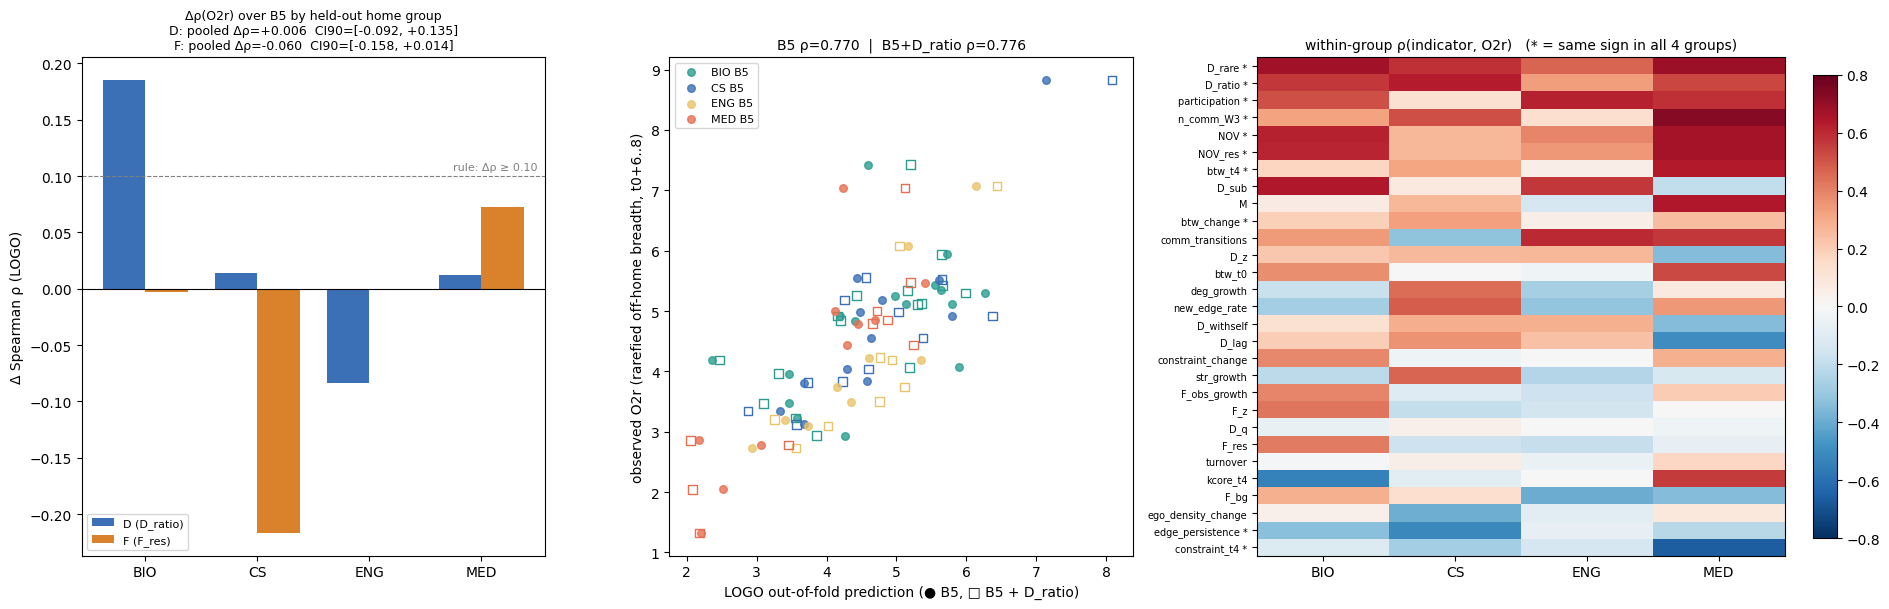

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.2), gridspec_kw={"width_ratios": [1, 1, 1.25]})

# (a) per-group delta rho
ax = axes[0]
w = 0.38
for i, key in enumerate(SCREENED):
    cr = result["candidates"][key]
    vals = [cr["per_group_delta_rho"].get(g, np.nan) for g in groups]
    ax.bar(np.arange(len(groups)) + (i - 0.5) * w, vals, w, label=f"{key} ({cr['feature']})",
           color=["#3b6fb6", "#d9822b"][i])
ax.set_xticks(range(len(groups)), groups)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(0.10, color="grey", ls="--", lw=0.8)
ax.text(len(groups) - 0.5, 0.105, "rule: Δρ ≥ 0.10", ha="right", fontsize=8, color="grey")
txt = "\n".join(f"{k}: pooled Δρ={result['candidates'][k]['delta_rho']:+.3f}  CI90=[{result['candidates'][k]['CI90'][0]:+.3f}, "
                f"{result['candidates'][k]['CI90'][1]:+.3f}]" for k in SCREENED)
ax.set_title("Δρ(O2r) over B5 by held-out home group\n" + txt, fontsize=9)
ax.set_ylabel("Δ Spearman ρ (LOGO)")
ax.legend(fontsize=8, loc="lower left")

# (b) OOF predictions
ax = axes[1]
oof = result["_oof"]
y_obs = main_df.set_index("concept").loc[oof["index"], "O2r"].to_numpy(float)
grp = main_df.set_index("concept").loc[oof["index"], "group"].to_numpy()
cols = {"BIO": "#2a9d8f", "CS": "#3b6fb6", "ENG": "#e9c46a", "MED": "#e76f51"}
for g in groups:
    m = grp == g
    ax.scatter(np.asarray(oof["base"])[m], y_obs[m], c=cols[g], marker="o", s=30, alpha=0.8, label=f"{g} B5")
    ax.scatter(np.asarray(oof["D_ratio"])[m], y_obs[m], facecolors="none", edgecolors=cols[g], marker="s", s=38)
ax.set_xlabel("LOGO out-of-fold prediction (● B5, □ B5 + D_ratio)")
ax.set_ylabel("observed O2r (rarefied off-home breadth, t0+6..8)")
ax.set_title(f"B5 ρ={srho(np.asarray(oof['base']), y_obs):.3f}  |  B5+D_ratio ρ={srho(np.asarray(oof['D_ratio']), y_obs):.3f}",
             fontsize=10)
ax.legend(fontsize=8)

# (c) portability heatmap (network indicators only)
ax = axes[2]
net = prt[~prt.index.isin(B5)]
H = net[[f"rho_{g}" for g in groups]].to_numpy(float)
im = ax.imshow(H, cmap="RdBu_r", vmin=-0.8, vmax=0.8, aspect="auto")
ax.set_xticks(range(len(groups)), groups)
ax.set_yticks(range(len(net)), [f"{i}{' *' if net.loc[i, 'same_sign_groups'] == 4 else ''}" for i in net.index], fontsize=7)
ax.set_title("within-group ρ(indicator, O2r)   (* = same sign in all 4 groups)", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

### Interpretation
* **Point estimates match the full run exactly.** B5 alone predicts later cross-disciplinary breadth well
  (ρ ≈ 0.77 under leave-one-domain-out). Adding the structural-diversity indicator D_ratio moves Δρ by about +0.006, and
  F_res lowers it. Neither candidate meets the pre-registered rule (Δρ ≥ 0.10 with a CI90 lower bound > 0). The honest
  outcome is a **null screen**: D is carried forward only as the best available result.
* **Portability (RQ1):** several diversity/brokerage indicators (D_ratio, D_rare, participation, NOV_res) correlate with `O2r`
  in all four domains, but they are **redundant** with B5's breadth features. Degree, strength and new-edge growth are
  CS-only signals. This is a domain-specific negative result.
* **Bootstrap size:** the CIs here come from `N_BOOT` resamples; 2,000 is the original setting. Smaller values, such as
  200, run in seconds and give the same point estimates, with noisier intervals.